# task 3 -> domain generalization on pacs

## imports

In [1]:
# !pip install -q pyarrow

In [2]:
from pathlib import Path
import copy
import io
import json
import math
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from tqdm.auto import tqdm


SEED = 6304 #same seed as task 2
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'using device {device}')
if torch.cuda.is_available():
    print(f'gpu {torch.cuda.get_device_name(0)}  '
          f'memory {torch.cuda.get_device_properties(0).total_memory / 1024 ** 3:.0f} gb  '
          f'capability {".".join(str(v) for v in torch.cuda.get_device_capability(0))}')
print(f'torch {torch.__version__}  cuda {torch.version.cuda}  cudnn {torch.backends.cudnn.version()}')

DATA_DIR = Path('./data')
OUTPUT_DIR = Path('./outputs/task3_dg')
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
SHARED_DIR = Path('../shared') #task 2 splits + erm checkpoint, nothing from sketch
TASK2_OUTPUT_DIR = Path('../task2/outputs/task2_uda') #has sketch numbers, only read in the final cross task cell
for directory in [DATA_DIR, OUTPUT_DIR, CHECKPOINT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

using device cuda
gpu NVIDIA RTX PRO 6000 Blackwell Server Edition  memory 95 gb  capability 12.0
torch 2.11.0+cu128  cuda 12.8  cudnn 91900


/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## global env variables ->

In [3]:
#anything shared w task 2 has the same value there (splits, init, preprocessing, optimiser, budget, seed etc)
CLASS_NAMES = ['dog', 'elephant', 'giraffe', 'guitar', 'horse', 'house', 'person']
NUM_CLASSES = 7
FEATURE_DIMENSION = 512

SOURCE_DOMAINS = ['photo', 'art_painting', 'cartoon']
TARGET_DOMAIN = 'sketch' #only named so it can be excluded

PACS_URL = ('https://huggingface.co/datasets/flwrlabs/pacs/resolve/' #same pinned file as task 2
            '394113073258ead631f617d2e13bb377c0715c4b/data/train-00000-of-00001.parquet')

RESIZE_SIZE = 256
CROP_SIZE = 224

SOURCE_BATCH_PER_DOMAIN = 8
SOURCE_BATCH = SOURCE_BATCH_PER_DOMAIN * len(SOURCE_DOMAINS)
EVAL_BATCH_SIZE = 128
NUM_WORKERS_PER_LOADER = 2

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 30
PATIENCE = 5

DG_WEIGHT = 1.0 #main comparison value, fixed by the assignment
MMD_BANDWIDTH_FACTORS = [0.5, 1.0, 2.0] #same kernels as task 2
SAM_RHO = 0.05

GRADIENT_CLIP_NORM = 1.0 #needed cuz the loaded erm was trained w clipping in task 2

DESIGN_STUDY_DG_WEIGHTS = [0.1, 1.0, 10.0] #fixed pre sketch, same weights as the task 2 lambda_mmd sweep

SEPARABILITY_TEST_FRACTION = 0.3
SEPARABILITY_C = 1.0

SHARPNESS_PER_DOMAIN = 32
SHARPNESS_RADIUS = 0.05

SPLIT_PATH = SHARED_DIR / 'pacs_splits_seed6304.json'
ERM_CHECKPOINT_PATH = SHARED_DIR / 'checkpoints' / 'source_only_erm.pt'
ERM_HISTORY_PATH = SHARED_DIR / 'source_only_erm_history.csv'

## pacs loading, source domains only

In [4]:
pacs_path = DATA_DIR / 'pacs.parquet'
if not pacs_path.exists(): #avoids redownloading 190mb
    torch.hub.download_url_to_file(PACS_URL, pacs_path)

#sketch dropped right after reading: bytes None, labels -1. row positions kept since the split indexes rows
pacs_frame = pd.read_parquet(pacs_path)
domains_all = pacs_frame['domain'].to_numpy()
source_mask = np.isin(domains_all, SOURCE_DOMAINS)

image_bytes = [entry['bytes'] if keep else None for entry, keep in zip(pacs_frame['image'], source_mask)]
labels_all = np.where(source_mask, pacs_frame['label'].to_numpy(), -1)
del pacs_frame

print(f'source images kept {int(source_mask.sum())}  rows withheld until the lock {int((~source_mask).sum())}')

source images kept 6062  rows withheld until the lock 3929


In [5]:
split_record = json.loads(SPLIT_PATH.read_text()) #from ../shared not recomputed
assert split_record['seed'] == SEED and split_record['pacs_url'] == PACS_URL, 'the split file does not match this protocol'
assert split_record['source_domains'] == SOURCE_DOMAINS
splits = split_record['splits']

for domain in SOURCE_DOMAINS:
    assert all(domains_all[row] == domain for row in splits[domain]['train'] + splits[domain]['val'])
    print(f"{domain:13s} train {len(splits[domain]['train']):5d}  val {len(splits[domain]['val']):4d}")

photo         train  1336  val  334
art_painting  train  1638  val  410
cartoon       train  1875  val  469


## transforms, datasets and loaders

In [6]:
pretrained_preset = ResNet18_Weights.IMAGENET1K_V1.transforms()
NORMALIZATION_MEAN = pretrained_preset.mean
NORMALIZATION_STD = pretrained_preset.std

train_transform = transforms.Compose([
    transforms.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    transforms.RandomCrop(CROP_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZATION_MEAN, NORMALIZATION_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    transforms.CenterCrop(CROP_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(NORMALIZATION_MEAN, NORMALIZATION_STD),
])


class PACSImages(Dataset):
    #same as task 2, sketch rows are None so decoding one fails loudly
    def __init__(self, rows, transform, labels):
        self.rows = np.asarray(rows)
        self.transform = transform
        self.labels = labels

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, position):
        row = self.rows[position]
        image = self.transform(Image.open(io.BytesIO(image_bytes[row])).convert('RGB'))
        return image, int(self.labels[row])


def make_source_loaders():
    source_loaders = {}
    for domain_index, domain in enumerate(SOURCE_DOMAINS):
        source_loaders[domain] = DataLoader(
            PACSImages(splits[domain]['train'], train_transform, labels_all),
            batch_size=SOURCE_BATCH_PER_DOMAIN, shuffle=True,
            drop_last=True, #8 per domain every step
            num_workers=NUM_WORKERS_PER_LOADER, pin_memory=torch.cuda.is_available(),
            persistent_workers=True,
            generator=torch.Generator().manual_seed(SEED + domain_index),
        )
    return source_loaders


def cycle_forever(loader):
    while True: #sources differ in size so each restarts on its own
        for batch in loader:
            yield batch


source_val_loaders = {
    domain: DataLoader(PACSImages(splits[domain]['val'], eval_transform, labels_all), batch_size=EVAL_BATCH_SIZE,
                       shuffle=False, num_workers=NUM_WORKERS_PER_LOADER, pin_memory=torch.cuda.is_available())
    for domain in SOURCE_DOMAINS
}

total_source_train = sum(len(splits[domain]['train']) for domain in SOURCE_DOMAINS)
STEPS_PER_EPOCH = math.ceil(total_source_train / SOURCE_BATCH)
print(f'pooled source train {total_source_train}  steps per epoch {STEPS_PER_EPOCH}')

pooled source train 4849  steps per epoch 203


## model and the batchnorm policy

In [7]:
class PACSClassifier(nn.Module): #same class as task 2 so the erm weights load unchanged
    def __init__(self):
        super().__init__()
        self.backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.backbone.fc = nn.Identity()
        self.classifier = nn.Linear(FEATURE_DIMENSION, NUM_CLASSES)

    def forward(self, images):
        features = self.backbone(images) #(n, 512)
        return features, self.classifier(features)


def freeze_batchnorm_statistics(model):
    #bn running stats stay at imagenet, gamma/beta still train. must follow every train(), covers both sam passes
    for module in model.modules():
        if isinstance(module, nn.BatchNorm2d):
            module.eval()


def build_model():
    torch.manual_seed(SEED)
    return PACSClassifier().to(device)

## dan-dg and sam

In [8]:
#both functions copied unchanged from task 2 so dan and dan-dg differ only in which domains get aligned

def pairwise_squared_distances(features):
    squared_norms = features.pow(2).sum(dim=1, keepdim=True) #(n, 1)
    return (squared_norms + squared_norms.T - 2 * features @ features.T).clamp_min(0) #(n, n)


def multi_kernel_mmd(source_features, target_features, bandwidth_factors=MMD_BANDWIDTH_FACTORS):
    combined = torch.cat([source_features, target_features])
    squared_distances = pairwise_squared_distances(combined)

    number_of_points = combined.size(0)
    off_diagonal = ~torch.eye(number_of_points, dtype=torch.bool, device=combined.device)
    median_distance = squared_distances[off_diagonal].detach().median().clamp_min(1e-8) #median bw per domain pair, detached

    kernel = sum(torch.exp(-squared_distances / (factor * median_distance)) for factor in bandwidth_factors)

    #unbiased estimator (same as task 2), diagonal k(x,x)=3 excluded, it would swamp the mmd at 8 per domain
    number_of_source = source_features.size(0)
    number_of_target = combined.size(0) - number_of_source

    within_source = kernel[:number_of_source, :number_of_source]
    within_target = kernel[number_of_source:, number_of_source:]
    source_source = (within_source.sum() - within_source.diagonal().sum()) / (number_of_source * (number_of_source - 1))
    target_target = (within_target.sum() - within_target.diagonal().sum()) / (number_of_target * (number_of_target - 1))
    source_target = kernel[:number_of_source, number_of_source:].mean()

    return source_source + target_target - 2 * source_target #can go slightly negative, expected


def pairwise_source_mmd(features):
    #batch stacked photo, art, cartoon (8 each) so pairs recovered by position, mean over the 3 pairs
    per_domain = features.split(SOURCE_BATCH_PER_DOMAIN) #3 x (8, 512)
    pair_penalties = [multi_kernel_mmd(per_domain[first], per_domain[second])
                      for first in range(len(SOURCE_DOMAINS)) for second in range(first + 1, len(SOURCE_DOMAINS))]
    return torch.stack(pair_penalties).mean()


def sam_step(model, optimizer, images, labels, rho):
    #non adaptive sam, one global l2 norm

    _, logits = model(images) #pass 1 at theta
    loss = F.cross_entropy(logits, labels)
    optimizer.zero_grad()
    loss.backward()

    parameters = [parameter for parameter in model.parameters() if parameter.grad is not None]
    gradient_norm = torch.norm(torch.stack([parameter.grad.norm(2) for parameter in parameters]), 2)
    scale = rho / (gradient_norm + 1e-12)

    perturbations = []
    with torch.no_grad():
        for parameter in parameters:
            perturbation = parameter.grad * scale
            parameter.add_(perturbation) #theta + eps
            perturbations.append(perturbation)

    optimizer.zero_grad()
    _, perturbed_logits = model(images) #pass 2 at theta + eps, bn still frozen
    perturbed_loss = F.cross_entropy(perturbed_logits, labels)
    perturbed_loss.backward()

    #back to theta but keep the theta + eps grad, adamw steps from the original weights
    with torch.no_grad():
        for parameter, perturbation in zip(parameters, perturbations):
            parameter.sub_(perturbation)
    torch.nn.utils.clip_grad_norm_(parameters, GRADIENT_CLIP_NORM) #clips the theta + eps grad adamw steps with
    optimizer.step()
    return loss.item(), perturbed_loss.item()

## evaluation helpers

In [9]:
@torch.no_grad()
def predict_loader(model, loader):
    model.eval()
    all_labels, all_predictions, all_features = [], [], []
    for images, labels in loader:
        features, logits = model(images.to(device, non_blocking=True))
        all_labels.append(labels)
        all_predictions.append(logits.argmax(dim=1).cpu())
        all_features.append(features.cpu())
    return torch.cat(all_labels).numpy(), torch.cat(all_predictions).numpy(), torch.cat(all_features).numpy()


def classification_metrics(labels, predictions):
    return {
        'accuracy': 100 * float((labels == predictions).mean()),
        'macro_f1': 100 * f1_score(labels, predictions, average='macro', labels=list(range(NUM_CLASSES)), zero_division=0),
    }


def evaluate_source_validation(model):
    row = {}
    for domain in SOURCE_DOMAINS:
        labels, predictions, _ = predict_loader(model, source_val_loaders[domain])
        metrics = classification_metrics(labels, predictions)
        row[f'{domain}_accuracy'] = metrics['accuracy']
        row[f'{domain}_macro_f1'] = metrics['macro_f1']
    for metric in ('accuracy', 'macro_f1'):
        values = [row[f'{domain}_{metric}'] for domain in SOURCE_DOMAINS]
        row[f'mean_source_{metric}'] = float(np.mean(values))
        row[f'worst_source_{metric}'] = float(np.min(values))
        row[f'worst_source_domain_by_{metric}'] = SOURCE_DOMAINS[int(np.argmin(values))]
    return row

## the shared training loop

In [10]:
def train_run(run_name, method, dg_weight=DG_WEIGHT, rho=SAM_RHO):
    #dan-dg and sam share init, batches, optimiser, budget + early stopping w task 2 erm, only the objective differs
    model = build_model()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    source_iterators = {domain: cycle_forever(loader) for domain, loader in make_source_loaders().items()}

    history = []
    best_score = -1.0
    best_state = None
    best_epoch = 0
    epochs_without_improvement = 0
    run_start = time.time()

    for epoch in range(MAX_EPOCHS):
        epoch_start = time.time()
        model.train()
        freeze_batchnorm_statistics(model)

        classification_loss_sum = 0.0
        mmd_penalty_sum = 0.0
        perturbed_loss_sum = 0.0

        for _ in tqdm(range(STEPS_PER_EPOCH), desc=f'{run_name} epoch {epoch + 1}', leave=False):
            source_batches = [next(source_iterators[domain]) for domain in SOURCE_DOMAINS] #fixed order pairwise_source_mmd relies on
            images = torch.cat([batch_images for batch_images, _ in source_batches]).to(device, non_blocking=True)
            labels = torch.cat([batch_labels for _, batch_labels in source_batches]).to(device, non_blocking=True)

            if method == 'dan_dg':
                features, logits = model(images)
                classification_loss = F.cross_entropy(logits, labels)
                mmd_penalty = pairwise_source_mmd(features)
                total_loss = classification_loss + dg_weight * mmd_penalty
                optimizer.zero_grad()
                total_loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRADIENT_CLIP_NORM)
                optimizer.step()
                classification_loss_sum += classification_loss.item()
                mmd_penalty_sum += mmd_penalty.item()
            else:
                classification_loss, perturbed_loss = sam_step(model, optimizer, images, labels, rho)
                classification_loss_sum += classification_loss
                perturbed_loss_sum += perturbed_loss

        validation = evaluate_source_validation(model) #selection on source val only
        epoch_row = {
            'run': run_name,
            'method': method,
            'epoch': epoch + 1,
            'classification_loss': classification_loss_sum / STEPS_PER_EPOCH,
            'mmd_penalty': mmd_penalty_sum / STEPS_PER_EPOCH if method == 'dan_dg' else float('nan'),
            'sam_perturbed_loss': perturbed_loss_sum / STEPS_PER_EPOCH if method == 'sam' else float('nan'),
            'epoch_seconds': time.time() - epoch_start,
            **validation,
        }
        history.append(epoch_row)

        extra = (f"mmd {epoch_row['mmd_penalty']:.4f}" if method == 'dan_dg'
                 else f"perturbed {epoch_row['sam_perturbed_loss']:.4f}")
        print(
            f"{run_name} epoch {epoch + 1:02d}/{MAX_EPOCHS} | cls {epoch_row['classification_loss']:.4f} | {extra} | "
            + ' | '.join(f"{domain} f1 {validation[f'{domain}_macro_f1']:.2f}" for domain in SOURCE_DOMAINS)
            + f" | mean f1 {validation['mean_source_macro_f1']:.2f}"
        )

        if validation['mean_source_macro_f1'] > best_score:
            best_score = validation['mean_source_macro_f1']
            best_epoch = epoch + 1
            best_state = {name: tensor.detach().cpu().clone() for name, tensor in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= PATIENCE:
                print(f'{run_name} stopped early after epoch {epoch + 1}, best epoch {best_epoch}')
                break

    model.load_state_dict(best_state)
    torch.save(best_state, CHECKPOINT_DIR / f'{run_name}.pt')

    run_config = {
        'run': run_name, 'method': method,
        'dg_weight': dg_weight if method == 'dan_dg' else None, 'sam_rho': rho if method == 'sam' else None,
        'learning_rate': LEARNING_RATE, 'weight_decay': WEIGHT_DECAY, 'seed': SEED,
        'source_batch_per_domain': SOURCE_BATCH_PER_DOMAIN, 'max_epochs': MAX_EPOCHS, 'patience': PATIENCE,
        'steps_per_epoch': STEPS_PER_EPOCH, 'epochs_trained': len(history), 'best_epoch': best_epoch,
        'best_mean_source_macro_f1': best_score, 'seconds': time.time() - run_start,
    }

    optimizer.state.clear()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return model.cpu(), pd.DataFrame(history), run_config

## experiment 1 : erm baseline, loaded from task 2

In [11]:
#hypothesis -> three diverse labelled sources may already be enough for sketch. erm loaded from task 2, not retrained
models = {}
histories = {}
run_configs = {}

models['erm'] = PACSClassifier()
models['erm'].load_state_dict(torch.load(ERM_CHECKPOINT_PATH, map_location='cpu'), strict=True) #strict, not retrained
histories['erm'] = pd.read_csv(ERM_HISTORY_PATH).assign(run='erm', method='erm')
run_configs['erm'] = {'run': 'erm', 'method': 'erm', 'loaded_from': str(ERM_CHECKPOINT_PATH), 'retrained': False,
                      'epochs_trained': len(histories['erm'])}

erm_source = evaluate_source_validation(models['erm'].to(device))
models['erm'] = models['erm'].cpu()
display(pd.DataFrame([erm_source]).round(2))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

 15%|█▌        | 6.75M/44.7M [00:00<00:00, 70.3MB/s]

 43%|████▎     | 19.2M/44.7M [00:00<00:00, 106MB/s] 

 70%|██████▉   | 31.1M/44.7M [00:00<00:00, 114MB/s]

 97%|█████████▋| 43.1M/44.7M [00:00<00:00, 118MB/s]

100%|██████████| 44.7M/44.7M [00:00<00:00, 112MB/s]

,photo_accuracy,photo_macro_f1,art_painting_accuracy,art_painting_macro_f1,cartoon_accuracy,cartoon_macro_f1,mean_source_accuracy,worst_source_accuracy,worst_source_domain_by_accuracy,mean_source_macro_f1,worst_source_macro_f1,worst_source_domain_by_macro_f1
0,96.11,95.61,90.49,90.45,94.67,95.05,93.76,90.49,art_painting,93.7,90.45,art_painting


## experiment 2 : dan-dg, pairwise source domain alignment

In [12]:
#hypothesis -> removing features that split photo/art/cartoon helps sketch if those are what fail there. but mmd is
#marginal and can mix classes, which would show as lower source val and lower separability together
models['dan_dg'], histories['dan_dg'], run_configs['dan_dg'] = train_run('dan_dg', 'dan_dg', dg_weight=DG_WEIGHT)

dan_dg epoch 1:   0%|          | 0/203 [00:00<?, ?it/s]

dan_dg epoch 1:   0%|          | 1/203 [00:01<04:22,  1.30s/it]

dan_dg epoch 1:   3%|▎         | 6/203 [00:01<00:35,  5.59it/s]

dan_dg epoch 1:   5%|▌         | 11/203 [00:01<00:17, 10.88it/s]

dan_dg epoch 1:   8%|▊         | 16/203 [00:01<00:11, 16.35it/s]

...

dan_dg epoch 11:  90%|█████████ | 183/203 [00:03<00:00, 61.66it/s]

dan_dg epoch 11:  94%|█████████▎| 190/203 [00:03<00:00, 59.73it/s]

dan_dg epoch 11:  97%|█████████▋| 196/203 [00:03<00:00, 59.41it/s]

dan_dg epoch 11: 100%|██████████| 203/203 [00:03<00:00, 60.26it/s]

dan_dg epoch 11/30 | cls 0.0909 | mmd 0.0024 | photo f1 94.98 | art_painting f1 87.56 | cartoon f1 92.45 | mean f1 91.67
dan_dg stopped early after epoch 11, best epoch 6


## experiment 3 : sam, parameter space stability

In [13]:
#hypothesis -> sam removes no domain info, if it helps sketch its via a flatter source solution not invariance
models['sam'], histories['sam'], run_configs['sam'] = train_run('sam', 'sam', rho=SAM_RHO)

sam epoch 1:   0%|          | 0/203 [00:00<?, ?it/s]

sam epoch 1:   0%|          | 1/203 [00:00<02:20,  1.43it/s]

sam epoch 1:   3%|▎         | 6/203 [00:00<00:20,  9.58it/s]

sam epoch 1:   5%|▌         | 11/203 [00:00<00:11, 17.38it/s]

sam epoch 1:   8%|▊         | 17/203 [00:01<00:07, 25.65it/s]

...

sam epoch 20:  91%|█████████ | 185/203 [00:03<00:00, 52.67it/s]

sam epoch 20:  94%|█████████▍| 191/203 [00:03<00:00, 53.42it/s]

sam epoch 20:  97%|█████████▋| 197/203 [00:03<00:00, 52.18it/s]

sam epoch 20: 100%|██████████| 203/203 [00:03<00:00, 50.06it/s]

sam epoch 20/30 | cls 0.0041 | perturbed 0.0872 | photo f1 96.81 | art_painting f1 90.25 | cartoon f1 96.65 | mean f1 94.57
sam stopped early after epoch 20, best epoch 15


## experiment 5 : design study training, dan-dg at the other two lambda_dg values

In [14]:
#expectation (pre results) -> separability falls steadily 0.1->10, source val holds at 0.1 and 1 and slips at 10,
#sketch acc follows source val not separability, peaking at a low/moderate weight. lambda 1 reuses the dan-dg run
design_study_runs = {}
for dg_weight in DESIGN_STUDY_DG_WEIGHTS:
    if dg_weight == DG_WEIGHT:
        design_study_runs[dg_weight] = 'dan_dg'
        continue
    run_name = f'dan_dg_lambda_{dg_weight:g}'
    models[run_name], histories[run_name], run_configs[run_name] = train_run(run_name, 'dan_dg', dg_weight=dg_weight)
    design_study_runs[dg_weight] = run_name

dan_dg_lambda_0.1 epoch 1:   0%|          | 0/203 [00:00<?, ?it/s]

dan_dg_lambda_0.1 epoch 1:   0%|          | 1/203 [00:00<02:22,  1.42it/s]

dan_dg_lambda_0.1 epoch 1:   3%|▎         | 7/203 [00:00<00:17, 11.00it/s]

dan_dg_lambda_0.1 epoch 1:   6%|▋         | 13/203 [00:00<00:09, 20.29it/s]

dan_dg_lambda_0.1 epoch 1:   9%|▉         | 19/203 [00:01<00:06, 28.28it/s]

...

dan_dg_lambda_10 epoch 21:  90%|█████████ | 183/203 [00:03<00:00, 55.59it/s]

dan_dg_lambda_10 epoch 21:  93%|█████████▎| 189/203 [00:03<00:00, 55.77it/s]

dan_dg_lambda_10 epoch 21:  96%|█████████▌| 195/203 [00:03<00:00, 56.10it/s]

dan_dg_lambda_10 epoch 21:  99%|█████████▉| 201/203 [00:03<00:00, 55.12it/s]

dan_dg_lambda_10 epoch 21/30 | cls 1.7576 | mmd 0.0241 | photo f1 32.83 | art_painting f1 20.51 | cartoon f1 25.30 | mean f1 26.21
dan_dg_lambda_10 stopped early after epoch 21, best epoch 16


## training curves and saved configurations

,run,method,dg_weight,sam_rho,epochs_trained,best_epoch,best_mean_source_macro_f1
0,erm,erm,NaN,NaN,14,NaN,NaN
1,dan_dg,dan_dg,1.0,NaN,11,6.0,93.31
2,sam,sam,NaN,0.05,20,15.0,96.17
3,dan_dg_lambda_0.1,dan_dg,0.1,NaN,10,5.0,93.92
4,dan_dg_lambda_10,dan_dg,10.0,NaN,21,16.0,28.30


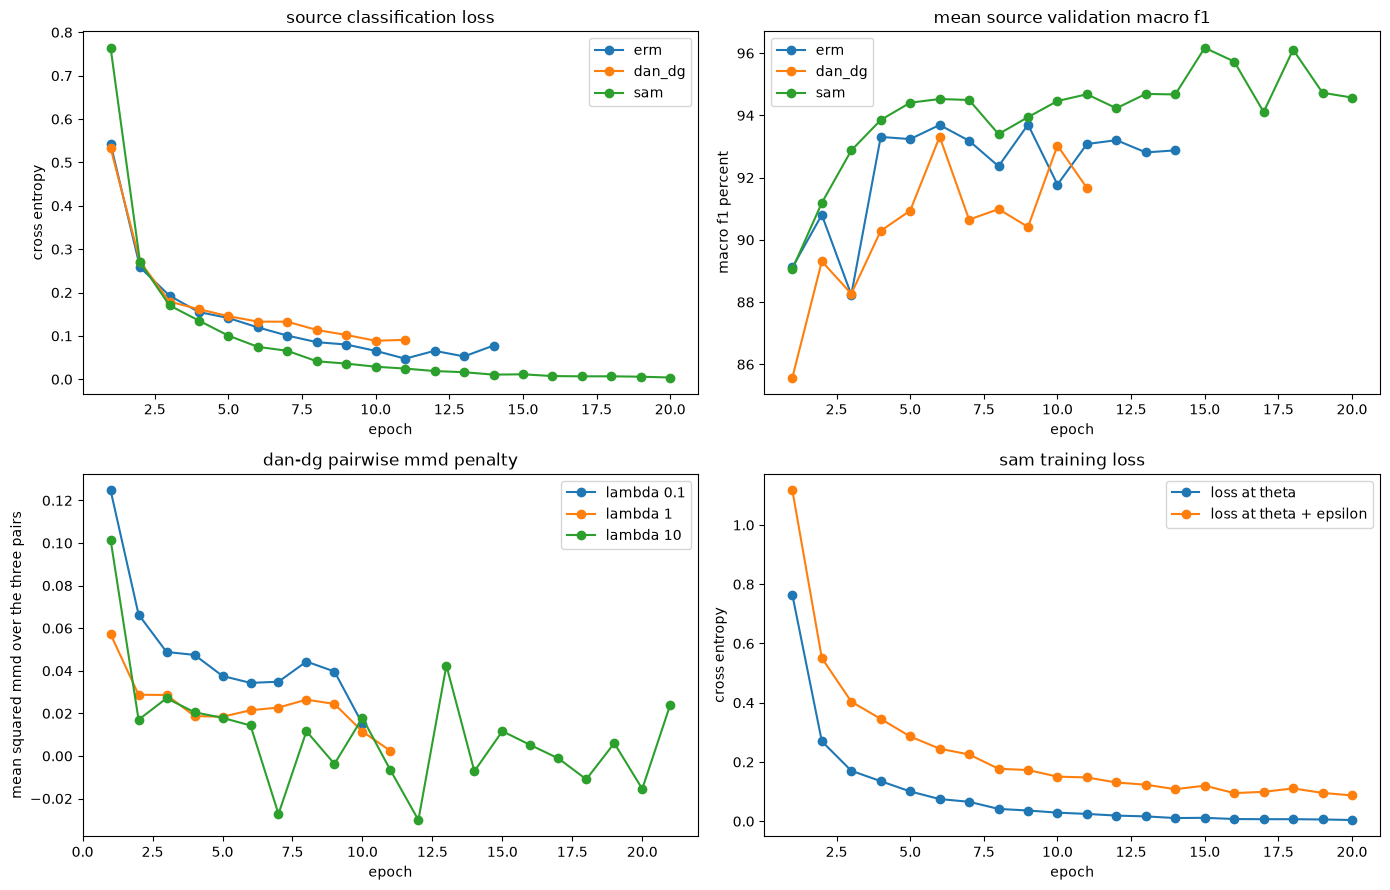

In [15]:
all_history = pd.concat(histories.values(), ignore_index=True)
all_history.to_csv(OUTPUT_DIR / 'training_history.csv', index=False)
(OUTPUT_DIR / 'run_configs.json').write_text(json.dumps(run_configs, indent=1))
display(pd.DataFrame(run_configs.values())[['run', 'method', 'dg_weight', 'sam_rho', 'epochs_trained', 'best_epoch',
                                           'best_mean_source_macro_f1']].round(2))

main_runs = ['erm', 'dan_dg', 'sam']
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for run_name in main_runs:
    run_history = histories[run_name]
    axes[0, 0].plot(run_history['epoch'], run_history['classification_loss'], marker='o', label=run_name)
    axes[0, 1].plot(run_history['epoch'], run_history['mean_source_macro_f1'], marker='o', label=run_name)

for dg_weight, run_name in design_study_runs.items():
    axes[1, 0].plot(histories[run_name]['epoch'], histories[run_name]['mmd_penalty'], marker='o', label=f'lambda {dg_weight:g}')

axes[1, 1].plot(histories['sam']['epoch'], histories['sam']['classification_loss'], marker='o', label='loss at theta')
axes[1, 1].plot(histories['sam']['epoch'], histories['sam']['sam_perturbed_loss'], marker='o', label='loss at theta + epsilon')

panel_labels = [
    (axes[0, 0], 'source classification loss', 'cross entropy'),
    (axes[0, 1], 'mean source validation macro f1', 'macro f1 percent'),
    (axes[1, 0], 'dan-dg pairwise mmd penalty', 'mean squared mmd over the three pairs'),
    (axes[1, 1], 'sam training loss', 'cross entropy'),
]
for axis, title, y_label in panel_labels:
    axis.set_title(title)
    axis.set_xlabel('epoch')
    axis.set_ylabel(y_label)
    axis.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_curves.png', dpi=180, bbox_inches='tight')
plt.show()

## source side diagnostics : source domain separability and the sharpness proxy

In [16]:
#both diagnostics use source val only, hence before the lock

def source_domain_separability(model):
    #domain probe on frozen features, chance 33.3%, lower = more source invariance (not better sketch)
    features_by_domain = [predict_loader(model, source_val_loaders[domain])[2] for domain in SOURCE_DOMAINS]

    per_domain = min(len(features) for features in features_by_domain) #balanced to the smallest source val split
    generator = np.random.default_rng(SEED)
    probe_features = np.concatenate([features[generator.choice(len(features), size=per_domain, replace=False)]
                                     for features in features_by_domain])
    probe_labels = np.repeat(np.arange(len(SOURCE_DOMAINS)), per_domain) #domain index not class

    train_features, test_features, train_labels, test_labels = train_test_split(
        probe_features, probe_labels, test_size=SEPARABILITY_TEST_FRACTION, stratify=probe_labels, random_state=SEED
    )
    probe = make_pipeline(StandardScaler(), LogisticRegression(C=SEPARABILITY_C, max_iter=5000)) #scaler on the 70% only, same as task 2
    probe.fit(train_features, train_labels)
    return 100 * probe.score(test_features, test_labels)


sharpness_generator = np.random.default_rng(SEED) #fixed 32 per source batch, reused for every model
sharpness_rows = np.concatenate([sharpness_generator.choice(splits[domain]['val'], size=SHARPNESS_PER_DOMAIN, replace=False)
                                 for domain in SOURCE_DOMAINS])
sharpness_images = torch.stack([eval_transform(Image.open(io.BytesIO(image_bytes[row])).convert('RGB')) for row in sharpness_rows])
sharpness_labels = torch.tensor(labels_all[sharpness_rows])


def sharpness_proxy(model):
    #L(theta+eps) - L(theta), radius 0.05, on a deep copy so the model isnt touched
    probe = copy.deepcopy(model).to(device)
    probe.eval()
    images = sharpness_images.to(device)
    labels = sharpness_labels.to(device)

    loss = F.cross_entropy(probe(images)[1], labels)
    probe.zero_grad()
    loss.backward()

    parameters = [parameter for parameter in probe.parameters() if parameter.grad is not None]
    gradient_norm = torch.norm(torch.stack([parameter.grad.norm(2) for parameter in parameters]), 2)
    with torch.no_grad():
        for parameter in parameters:
            parameter.add_(SHARPNESS_RADIUS * parameter.grad / (gradient_norm + 1e-12))
        perturbed_loss = F.cross_entropy(probe(images)[1], labels)

    return perturbed_loss.item() - loss.item(), loss.item()


source_diagnostics = []
for run_name, model in models.items():
    model = model.to(device)
    sharpness, base_loss = sharpness_proxy(model)
    source_diagnostics.append({
        'run': run_name,
        'source_domain_separability': source_domain_separability(model),
        'sharpness_proxy': sharpness,
        'sharpness_batch_loss': base_loss, #base loss so a small delta on a high loss isnt misread
    })
    models[run_name] = model.cpu()

source_diagnostics = pd.DataFrame(source_diagnostics).set_index('run')
source_diagnostics.to_csv(OUTPUT_DIR / 'source_diagnostics.csv')
display(source_diagnostics.round(4))

,source_domain_separability,sharpness_proxy,sharpness_batch_loss
run,,,
erm,84.7176,0.4590,0.1155
dan_dg,68.4385,0.4285,0.1756
sam,85.7143,0.1304,0.0903
dan_dg_lambda_0.1,83.3887,0.2227,0.0587
dan_dg_lambda_10,48.5050,40.3435,1.6716


## locked evaluation -> every task 3 checkpoint and setting above is fixed, sketch is loaded from here on

In [17]:
#sketch restored only now at its original row positions so nothing above changes
pacs_frame = pd.read_parquet(pacs_path)
target_rows = np.flatnonzero(pacs_frame['domain'].to_numpy() == TARGET_DOMAIN)
for row in target_rows:
    image_bytes[row] = pacs_frame['image'].iloc[row]['bytes']
labels_all[target_rows] = pacs_frame['label'].to_numpy()[target_rows]
del pacs_frame

target_eval_loader = DataLoader(
    PACSImages(target_rows, eval_transform, labels_all), batch_size=EVAL_BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS_PER_LOADER, pin_memory=torch.cuda.is_available()
)

evaluation = {}
for run_name, model in models.items():
    model = model.to(device)
    source_row = evaluate_source_validation(model)
    target_labels, target_predictions, _ = predict_loader(model, target_eval_loader)
    target_metrics = classification_metrics(target_labels, target_predictions)
    evaluation[run_name] = {
        **source_row,
        'sketch_accuracy': target_metrics['accuracy'],
        'sketch_macro_f1': target_metrics['macro_f1'],
        'target_labels': target_labels,
        'target_predictions': target_predictions,
    }
    models[run_name] = model.cpu()
    print(f"{run_name:18s} sketch acc {target_metrics['accuracy']:.2f}  mean source acc {source_row['mean_source_accuracy']:.2f}")

erm                sketch acc 65.18  mean source acc 93.76


dan_dg             sketch acc 71.93  mean source acc 93.55


sam                sketch acc 74.06  mean source acc 96.19


dan_dg_lambda_0.1  sketch acc 64.55  mean source acc 93.79


dan_dg_lambda_10   sketch acc 35.30  mean source acc 32.94


In [18]:
metric_columns = ([f'{domain}_{metric}' for domain in SOURCE_DOMAINS for metric in ('accuracy', 'macro_f1')]
                  + ['mean_source_accuracy', 'mean_source_macro_f1', 'worst_source_accuracy', 'worst_source_macro_f1',
                     'worst_source_domain_by_accuracy', 'sketch_accuracy', 'sketch_macro_f1'])

main_results = pd.DataFrame([{'method': run_name, **{column: evaluation[run_name][column] for column in metric_columns}}
                             for run_name in main_runs])
main_results['sketch_accuracy_change'] = main_results['sketch_accuracy'] - evaluation['erm']['sketch_accuracy']
main_results = main_results.join(source_diagnostics, on='method')

main_results.to_csv(OUTPUT_DIR / 'main_results.csv', index=False)
display(main_results.round(3))

,method,photo_accuracy,photo_macro_f1,art_painting_accuracy,art_painting_macro_f1,cartoon_accuracy,cartoon_macro_f1,mean_source_accuracy,mean_source_macro_f1,worst_source_accuracy,worst_source_macro_f1,worst_source_domain_by_accuracy,sketch_accuracy,sketch_macro_f1,sketch_accuracy_change,source_domain_separability,sharpness_proxy,sharpness_batch_loss
0,erm,96.108,95.613,90.488,90.451,94.670,95.049,93.755,93.704,90.488,90.451,art_painting,65.182,64.148,0.000,84.718,0.459,0.115
1,dan_dg,96.407,95.661,90.000,89.505,94.243,94.776,93.550,93.314,90.000,89.505,art_painting,71.927,71.920,6.745,68.439,0.428,0.176
2,sam,97.904,97.497,93.659,93.669,97.015,97.348,96.193,96.171,93.659,93.669,art_painting,74.065,75.327,8.883,85.714,0.130,0.090


In [19]:
per_class_rows = [] #house (80) and person (160) are tiny so they move in big steps
for run_name in main_runs:
    labels = evaluation[run_name]['target_labels']
    predictions = evaluation[run_name]['target_predictions']
    for class_index, class_name in enumerate(CLASS_NAMES):
        class_mask = labels == class_index
        per_class_rows.append({'method': run_name, 'class': class_name, 'images': int(class_mask.sum()),
                               'accuracy': 100 * float((predictions[class_mask] == class_index).mean())})

per_class = pd.DataFrame(per_class_rows).pivot(index='class', columns='method', values='accuracy')[main_runs]
per_class_change = per_class[['dan_dg', 'sam']].sub(per_class['erm'], axis=0)

per_class.to_csv(OUTPUT_DIR / 'per_class_sketch_accuracy.csv')
per_class_change.to_csv(OUTPUT_DIR / 'per_class_sketch_change.csv')
display(per_class.round(2))
display(per_class_change.round(2))

for run_name in ['dan_dg', 'sam']:
    print(f'{run_name:6s} largest gain {per_class_change[run_name].idxmax()} ({per_class_change[run_name].max():+.2f})'
          f'  largest loss {per_class_change[run_name].idxmin()} ({per_class_change[run_name].min():+.2f})')

method,erm,dan_dg,sam
class,,,
dog,23.83,26.42,38.86
elephant,80.68,87.97,92.84
giraffe,37.72,76.76,58.96
guitar,94.74,91.78,94.57
horse,88.73,84.68,83.82
house,76.25,98.75,95.00
person,84.38,40.62,90.00


method,dan_dg,sam
class,,
dog,2.59,15.03
elephant,7.30,12.16
giraffe,39.04,21.25
guitar,-2.96,-0.16
horse,-4.04,-4.90
house,22.50,18.75
person,-43.75,5.62


dan_dg largest gain giraffe (+39.04)  largest loss person (-43.75)
sam    largest gain giraffe (+21.25)  largest loss horse (-4.90)


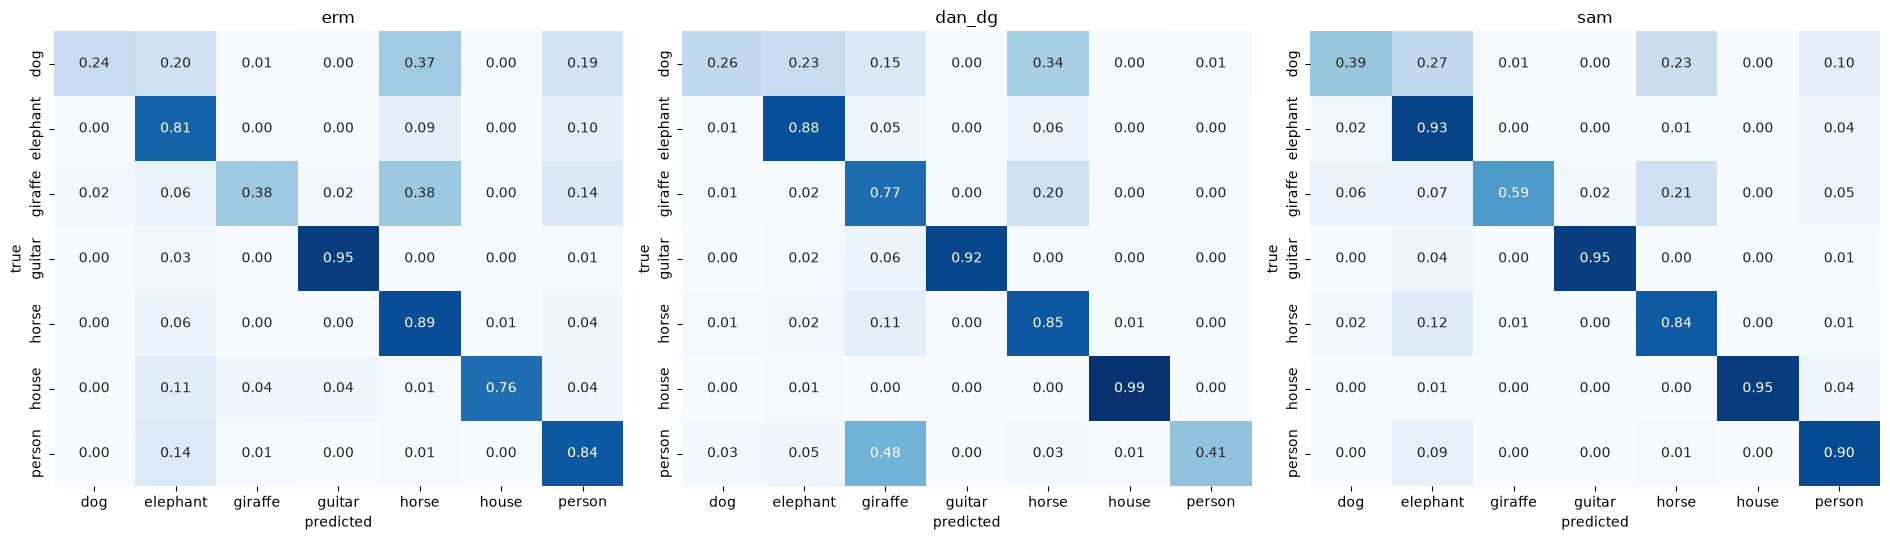

,method,true,predicted,images,share_of_true_class
0,erm,giraffe,horse,287,38.11
1,erm,dog,horse,286,37.05
2,erm,dog,elephant,153,19.82
3,dan_dg,dog,horse,264,34.20
4,dan_dg,dog,elephant,181,23.45
5,dan_dg,giraffe,horse,149,19.79
6,sam,dog,elephant,205,26.55
7,sam,dog,horse,176,22.80
8,sam,giraffe,horse,157,20.85


In [20]:
fig, axes = plt.subplots(1, len(main_runs), figsize=(19, 5.5))
confusion_rows = []

for axis, run_name in zip(axes, main_runs):
    labels = evaluation[run_name]['target_labels']
    predictions = evaluation[run_name]['target_predictions']
    counts = confusion_matrix(labels, predictions, labels=list(range(NUM_CLASSES)))
    row_normalised = counts / counts.sum(axis=1, keepdims=True) #row normalised, classes range 80 to 816 imgs

    sns.heatmap(row_normalised, annot=True, fmt='.2f', cmap='Blues', vmin=0, vmax=1, cbar=False,
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axis)
    axis.set_title(run_name)
    axis.set_xlabel('predicted')
    axis.set_ylabel('true')

    off_diagonal = counts.copy()
    np.fill_diagonal(off_diagonal, 0)
    for flat_index in np.argsort(off_diagonal.ravel())[::-1][:3]:
        true_class, predicted_class = np.unravel_index(flat_index, off_diagonal.shape)
        confusion_rows.append({'method': run_name, 'true': CLASS_NAMES[true_class], 'predicted': CLASS_NAMES[predicted_class],
                               'images': int(off_diagonal[true_class, predicted_class]),
                               'share_of_true_class': 100 * row_normalised[true_class, predicted_class]})

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sketch_confusion_matrices.png', dpi=180, bbox_inches='tight')
plt.show()

dominant_confusions = pd.DataFrame(confusion_rows)
dominant_confusions.to_csv(OUTPUT_DIR / 'dominant_confusions.csv', index=False)
display(dominant_confusions.round(2))

dan_dg lost 282 images erm had right, gained 547
sam    lost 153 images erm had right, gained 502


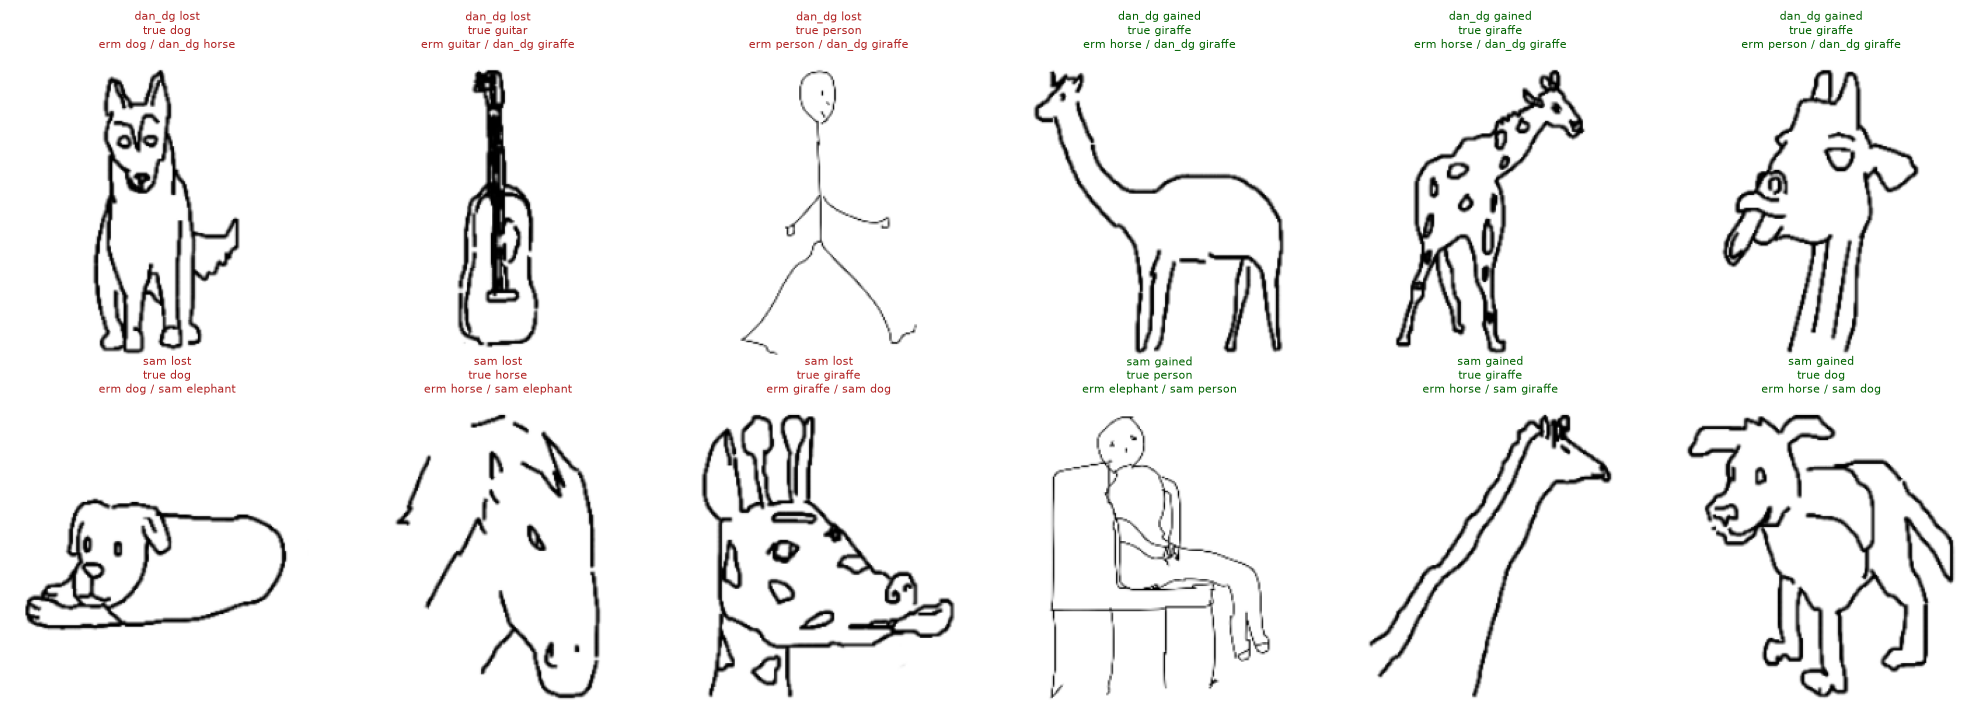

In [21]:
display_transform = transforms.Compose([transforms.Resize((RESIZE_SIZE, RESIZE_SIZE)), transforms.CenterCrop(CROP_SIZE)])
erm_predictions = evaluation['erm']['target_predictions']
target_labels = evaluation['erm']['target_labels']

examples_per_side = 3
fig, axes = plt.subplots(2, 2 * examples_per_side, figsize=(20, 7.2))

for row, run_name in enumerate(['dan_dg', 'sam']):
    method_predictions = evaluation[run_name]['target_predictions']
    lost = np.flatnonzero((erm_predictions == target_labels) & (method_predictions != target_labels))
    gained = np.flatnonzero((erm_predictions != target_labels) & (method_predictions == target_labels))
    shuffle = np.random.default_rng(SEED) #seeded pick of lost/gained cases, not hand picked

    chosen = [('lost', position) for position in shuffle.permutation(lost)[:examples_per_side]]
    chosen += [('gained', position) for position in shuffle.permutation(gained)[:examples_per_side]]

    for column in range(2 * examples_per_side):
        axis = axes[row, column]
        axis.axis('off')
        if column >= len(chosen):
            continue
        kind, position = chosen[column]
        image = display_transform(Image.open(io.BytesIO(image_bytes[target_rows[position]])).convert('RGB'))
        axis.imshow(image)
        axis.set_title(f'{run_name} {kind}\ntrue {CLASS_NAMES[target_labels[position]]}\n'
                       f'erm {CLASS_NAMES[erm_predictions[position]]} / {run_name} {CLASS_NAMES[method_predictions[position]]}',
                       fontsize=8, color='firebrick' if kind == 'lost' else 'darkgreen')

    print(f'{run_name:6s} lost {len(lost)} images erm had right, gained {len(gained)}')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sketch_transfer_cases.png', dpi=180, bbox_inches='tight')
plt.show()

In [22]:
#task 2 results read only here, after every task 3 decision is fixed
task2_results = pd.read_csv(TASK2_OUTPUT_DIR / 'main_results.csv').set_index('method')
task2_per_class = pd.read_csv(TASK2_OUTPUT_DIR / 'per_class_target_accuracy.csv').set_index('class')

erm_gap = evaluation['erm']['sketch_accuracy'] - task2_results.loc['source_only', 'target_accuracy'] #sanity check, should be ~0
print(f'erm sketch accuracy here minus task 2 source only: {erm_gap:+.4f}')

cross_task = pd.DataFrame([
    {'method': 'erm', 'task': 'shared', 'sees_sketch_during_training': False,
     'sketch_accuracy': evaluation['erm']['sketch_accuracy'], 'sketch_macro_f1': evaluation['erm']['sketch_macro_f1']},
    {'method': 'dan', 'task': 'task 2', 'sees_sketch_during_training': True,
     'sketch_accuracy': task2_results.loc['dan', 'target_accuracy'], 'sketch_macro_f1': task2_results.loc['dan', 'target_macro_f1']},
    {'method': 'dan_dg', 'task': 'task 3', 'sees_sketch_during_training': False,
     'sketch_accuracy': evaluation['dan_dg']['sketch_accuracy'], 'sketch_macro_f1': evaluation['dan_dg']['sketch_macro_f1']},
    {'method': 'sam', 'task': 'task 3', 'sees_sketch_during_training': False,
     'sketch_accuracy': evaluation['sam']['sketch_accuracy'], 'sketch_macro_f1': evaluation['sam']['sketch_macro_f1']},
])
cross_task['sketch_accuracy_change_vs_erm'] = cross_task['sketch_accuracy'] - evaluation['erm']['sketch_accuracy']
cross_task.to_csv(OUTPUT_DIR / 'cross_task_comparison.csv', index=False)
display(cross_task.round(2))

cross_task_per_class = pd.DataFrame({
    'erm': per_class['erm'],
    'dan (task 2)': task2_per_class['dan'],
    'dan_dg': per_class['dan_dg'],
    'sam': per_class['sam'],
})
cross_task_per_class.to_csv(OUTPUT_DIR / 'cross_task_per_class.csv')
display(cross_task_per_class.round(2))

erm sketch accuracy here minus task 2 source only: +0.0000


,method,task,sees_sketch_during_training,sketch_accuracy,sketch_macro_f1,sketch_accuracy_change_vs_erm
0,erm,shared,False,65.18,64.15,0.00
1,dan,task 2,True,56.91,55.31,-8.27
2,dan_dg,task 3,False,71.93,71.92,6.74
3,sam,task 3,False,74.06,75.33,8.88


,erm,dan (task 2),dan_dg,sam
class,,,,
dog,23.83,49.48,26.42,38.86
elephant,80.68,46.49,87.97,92.84
giraffe,37.72,50.20,76.76,58.96
guitar,94.74,80.76,91.78,94.57
horse,88.73,53.19,84.68,83.82
house,76.25,100.00,98.75,95.00
person,84.38,79.38,40.62,90.00


,dg_weight,run,mean_source_accuracy,mean_source_macro_f1,worst_source_accuracy,source_domain_separability,sketch_accuracy,sketch_macro_f1,sketch_accuracy_change_vs_erm
0,0.1,dan_dg_lambda_0.1,93.79,93.92,90.98,83.39,64.55,65.80,-0.64
1,1.0,dan_dg,93.55,93.31,90.00,68.44,71.93,71.92,6.74
2,10.0,dan_dg_lambda_10,32.94,28.30,22.44,48.50,35.30,27.59,-29.88


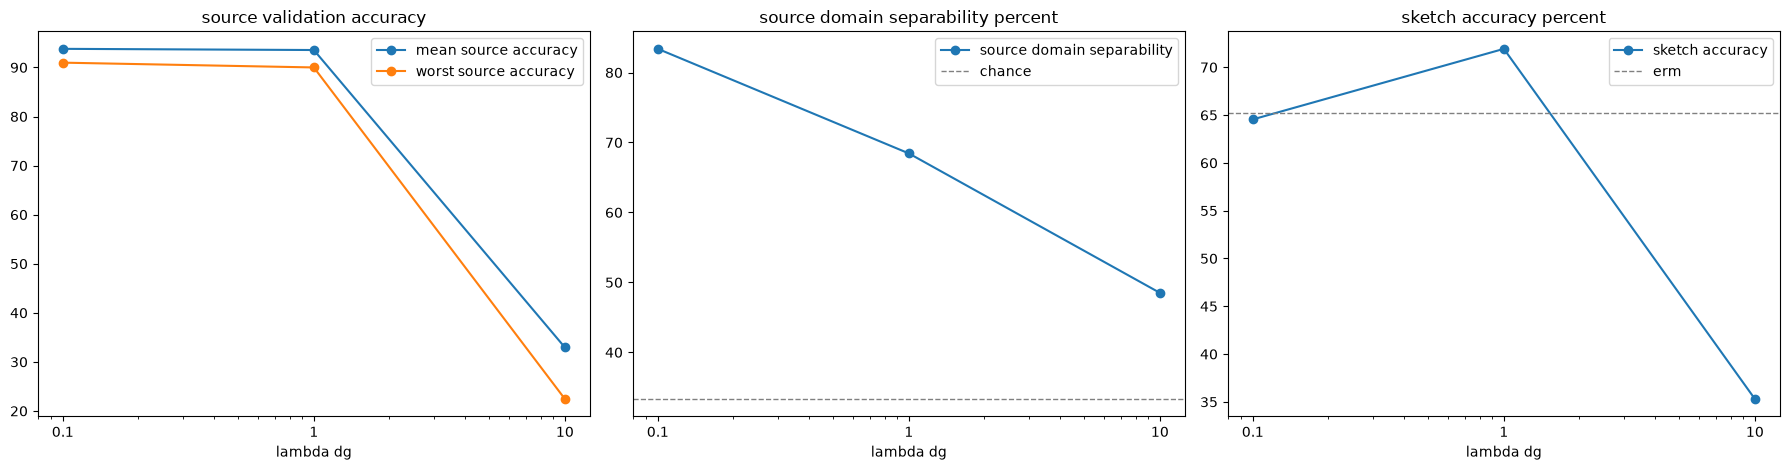

In [23]:
#main comparison stays at lambda_dg=1 and rho=0.05 whatever this sweep shows, no post hoc winner
design_rows = []
for dg_weight, run_name in design_study_runs.items():
    design_rows.append({
        'dg_weight': dg_weight,
        'run': run_name,
        'mean_source_accuracy': evaluation[run_name]['mean_source_accuracy'],
        'mean_source_macro_f1': evaluation[run_name]['mean_source_macro_f1'],
        'worst_source_accuracy': evaluation[run_name]['worst_source_accuracy'],
        'source_domain_separability': source_diagnostics.loc[run_name, 'source_domain_separability'],
        'sketch_accuracy': evaluation[run_name]['sketch_accuracy'],
        'sketch_macro_f1': evaluation[run_name]['sketch_macro_f1'],
    })

design_study = pd.DataFrame(design_rows)
design_study['sketch_accuracy_change_vs_erm'] = design_study['sketch_accuracy'] - evaluation['erm']['sketch_accuracy']
design_study.to_csv(OUTPUT_DIR / 'design_study_dg_weight.csv', index=False)
display(design_study.round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
panels = [
    (['mean_source_accuracy', 'worst_source_accuracy'], 'source validation accuracy'),
    (['source_domain_separability'], 'source domain separability percent'),
    (['sketch_accuracy'], 'sketch accuracy percent'),
]
for axis, (columns, title) in zip(axes, panels):
    for column in columns:
        axis.plot(design_study['dg_weight'], design_study[column], marker='o', label=column.replace('_', ' '))
    axis.set_xscale('log')
    axis.set_xticks(DESIGN_STUDY_DG_WEIGHTS)
    axis.set_xticklabels([f'{weight:g}' for weight in DESIGN_STUDY_DG_WEIGHTS])
    axis.set_xlabel('lambda dg')
    axis.set_title(title)
axes[0].legend()
axes[1].axhline(100 / 3, color='grey', linestyle='--', linewidth=1, label='chance')
axes[1].legend()
axes[2].axhline(evaluation['erm']['sketch_accuracy'], color='grey', linestyle='--', linewidth=1, label='erm')
axes[2].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'design_study_dg_weight.png', dpi=180, bbox_inches='tight')
plt.show()

if torch.cuda.is_available():
    torch.cuda.empty_cache()